# ta-seqscan Stop Detection

In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles
import nomad.stop_detection.dbscan as DBSCAN
from nomad.stop_detection.density_based import seqscan_labels
import nomad.stop_detection.density_based as SEQSCAN


import nomad.data as data_folder
from pathlib import Path

from nomad.city_gen import City
import pandas as pd
import datetime
import json
import matplotlib.dates as mdates
import pandas as pd
import nomad.generation.viz as viz
from nomad.traj_gen import Agent, condense_destinations
import nomad.stop_detection.utils as utils

In [3]:
# Parameters according to the config file
data_dir = Path(data_folder.__file__).parent
city = City.from_geopackage(data_dir / 'garden-city.gpkg')
buildings = gpd.read_parquet(data_dir / 'garden-city-buildings-mercator.parquet')

# Destination Diary for 2 stop trajectory

In [4]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=2, freq='90min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [90]*2  # in minutes

location = ['w-x17-y10'] + ['r-x19-y11']


destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

destinations = condense_destinations(destinations)
destinations

,datetime,timestamp,duration,location
0,2024-06-01 00:00:00-08:00,1717228800,90,w-x17-y10
1,2024-06-01 01:30:00-08:00,1717234200,90,r-x19-y11


In [5]:
seed = 33 #33
dist_thresh = 12/15
time_thresh=120
dur_min=5
min_pts = 3
ha=15/15

Charlie = Agent(identifier="Andres",
                city=city)

Charlie.generate_trajectory(destination_diary=destinations,
                            seed=seed,
                            dt=0.15)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=6,
                          seed=seed,
                          ha=ha)


/Users/caroltu/nomad/nomad/city_gen.py:1575: UserWarning: shortest_paths not initialized. Auto-initializing with callable_only=True. Call compute_shortest_paths() explicitly.
  warnings.warn("shortest_paths not initialized. Auto-initializing with callable_only=True. Call compute_shortest_paths() explicitly.", UserWarning)


### Plot normal stops

In [8]:
traj = Charlie.sparse_traj
labels = seqscan_labels(
    traj,
    dist_thresh=10/15,
    min_pts=3
)

# merged = traj.join(labels)

In [9]:
print(labels[labels != -1])

timestamp
1717228816    0
1717229268    0
1717229670    0
1717229937    0
1717231138    0
1717231367    0
1717231789    0
1717232016    0
1717232110    2
1717232727    2
1717232922    2
1717232936    2
1717232946    2
1717233052    2
1717233474    2
1717233495    2
1717233886    2
1717234262    3
1717234494    3
1717234499    3
1717235380    3
1717235476    3
1717236145    4
1717237408    4
1717237810    5
1717237974    5
1717238080    5
1717238352    5
1717239232    5
1717239349    0
1717239419    5
1717239463    0
Name: cluster, dtype: int64


### Remove overlaps

In [ ]:
# # Get adjusted cluster labels (not summary table)
# adjusted_labels = DBSCAN.ta_dbscan_labels(traj,
#                                 time_thresh=time_thresh,
#                                 dist_thresh=dist_thresh,
#                                 min_pts=min_pts,
#                                 remove_overlaps=True,
#                                 return_cores=False,
#                                 timestamp='timestamp')

# merged['cluster_adjusted'] = adjusted_labels

NameError: name 'merged' is not defined

In [ ]:
traj['cluster'] = labels

ValueError: 'cluster' is not a valid color value.

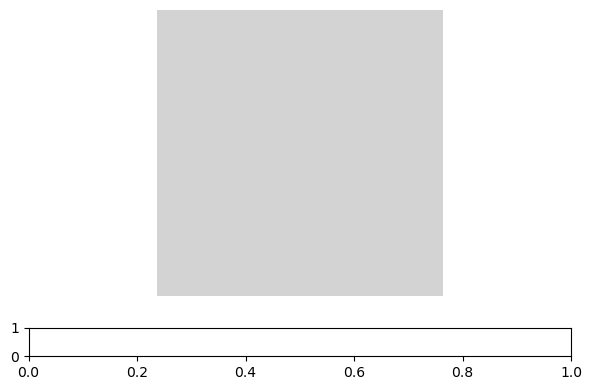

In [10]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(7,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})

# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.1, color='cluster', cmap='PiYG', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=5, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
#plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='PiYG', set_xlim=False, lw=1.3)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('normal_clusters.svg' , format='svg')
plt.savefig('normal_clusters.png' , format='png', dpi=300)
plt.show()